# Segmentação de letras - Parte 1
Começaremos pelas imagens que tem dimensões grandes mas que estão em condições adversas de luz: pouco contraste entre a letra e o fundo, imagem de captura ruim, fundo escuro...

## Abordagem: componentes conectados

Importando bibliotecas

In [1]:
import cv2 as cv
from skimage import measure
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
import math
import os
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

Função `plot_all(str directory)`: exibe todas as imagens que estão no diretório-raiz `directory`.

In [2]:
def plot_all(directory):
    # Extensões de imagem válidas
    valid_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

    # Coleta todos os caminhos de imagens (recursivamente)
    image_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if os.path.splitext(file)[1].lower() in valid_extensions:
                image_paths.append(os.path.join(root, file))

    # Aumente o número de colunas aqui
    n_cols = 5
    n_rows = -(-len(image_paths) // n_cols)  # arredonda pra cima

    # Ajuste do tamanho da figura
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2 * n_rows))
    axes = axes.flatten() if len(image_paths) > 1 else [axes]

    # Define tamanho máximo de exibição
    max_size = (600, 600)

    for ax, img_path in zip(axes, image_paths):
        try:
            # Abre imagem e corrige orientação EXIF automaticamente
            img = Image.open(img_path)
            img = ImageOps.exif_transpose(img)
            img = img.convert("RGB")

            # Redimensiona mantendo proporção
            img.thumbnail(max_size)

            # Exibe imagem
            ax.imshow(img)
            ax.set_title(os.path.basename(img_path), fontsize=8)
            ax.axis("off")
        except Exception as e:
            ax.set_title(f"Erro ao carregar:\n{os.path.basename(img_path)}", fontsize=8)
            ax.axis("off")

    # Remove subplots vazios
    for i in range(len(image_paths), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


## Etapa 1: Pré-processamento

Pasta raiz em `INPUT_ROOT_FOLDER`, pasta destino em `OUTPUT_ROOT_FOLDER`, com as transformações resultantes do pré-processamento.

In [ ]:
INPUT_ROOT_FOLDER = 'data/interim/data_1'
OUTPUT_ROOT_FOLDER = 'data_1/interim'

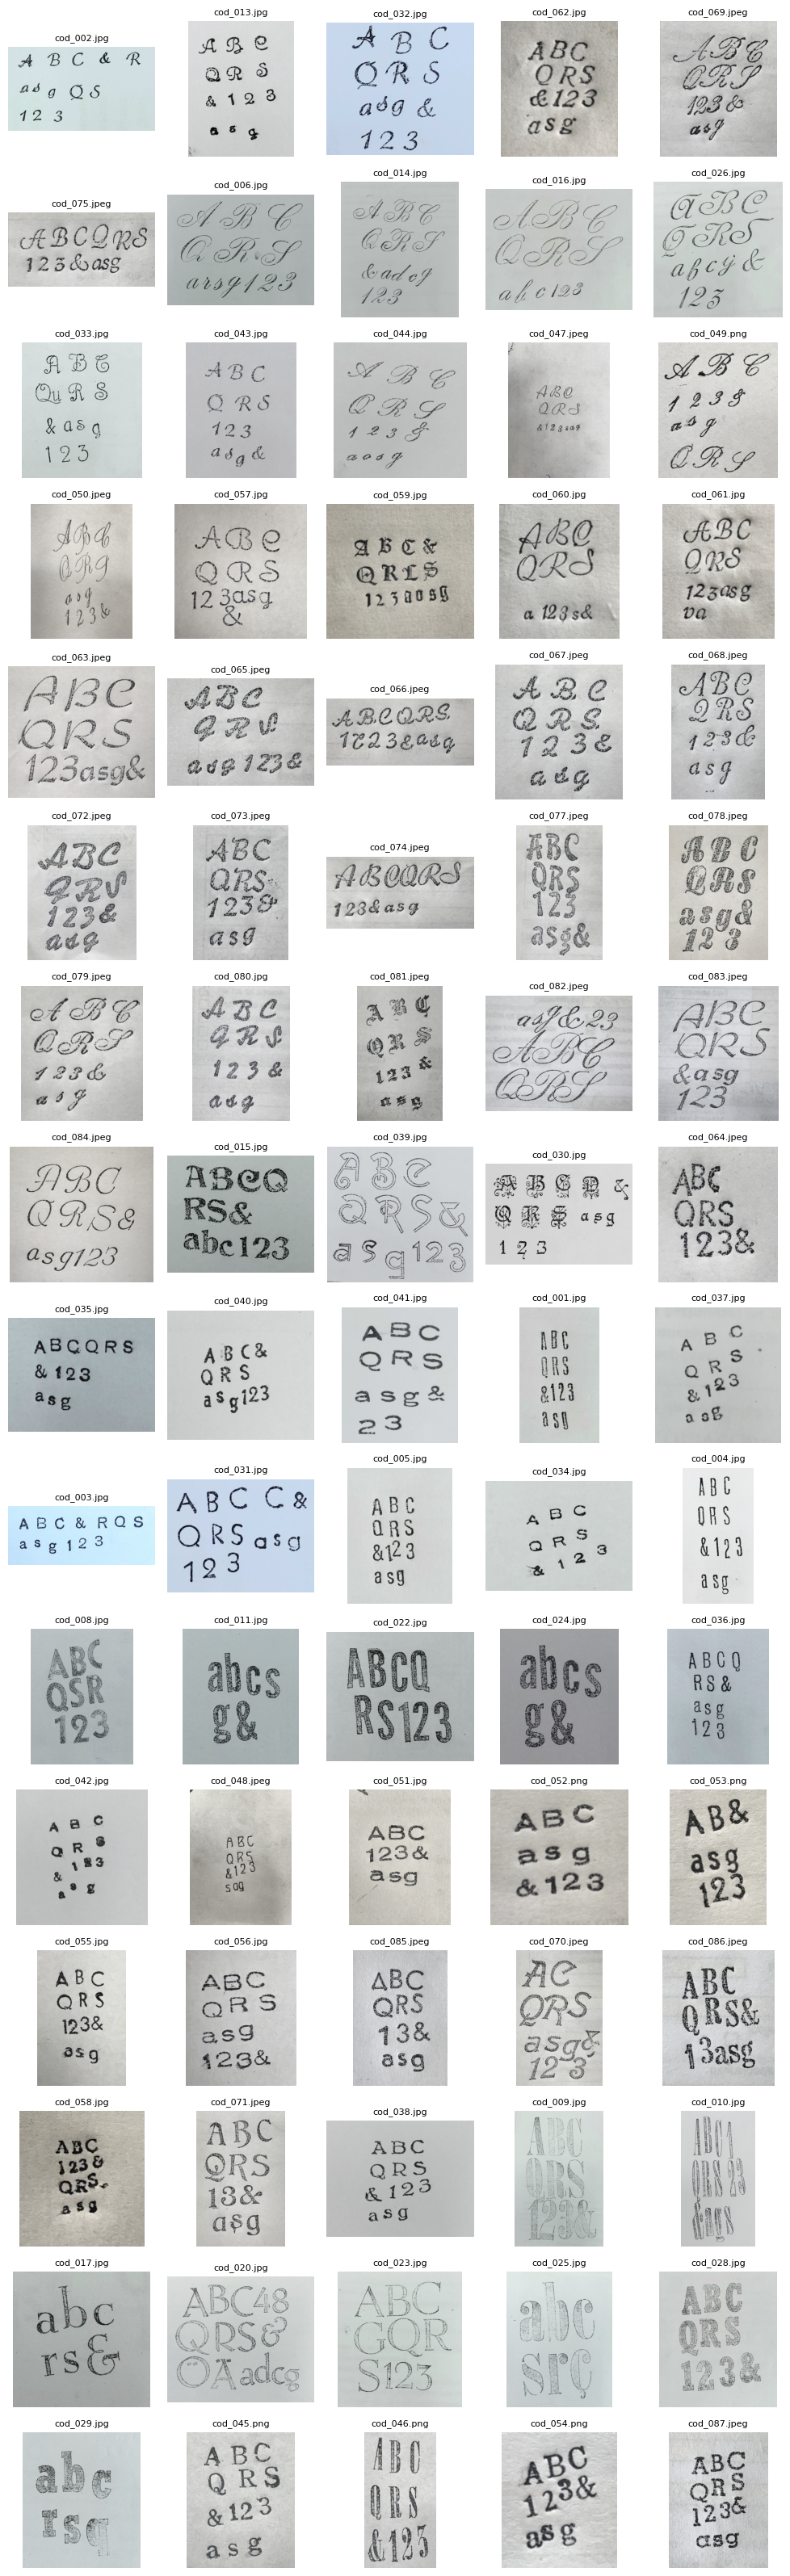

In [4]:
plot_all(f'{INPUT_ROOT_FOLDER}/raw')

### 1.1: Remoção de ruído e binarização
Para remoção de ruído, será aplicado filtro de mediana sobre as imagens, de kernel tamanho 15x15, para remoção de ruído 'sal e pimenta', seguido de binarização simples. Valores menores ou iguais a 127 são reduzidos a 0 (preto - idealmente, as letras), enquanto valores maiores que 127 são mudados a 255 (branco - idealmente, o fundo).

In [6]:
for current_path, subdirectories, files in os.walk(f'{INPUT_ROOT_FOLDER}/raw'):
        if not files: continue
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            style_name = os.path.basename(current_path)
            output_image_dir = os.path.join(f'{OUTPUT_ROOT_FOLDER}/binarized', style_name)
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"-> Style: '{style_name}', Image Code: '{image_base_name}'")
            print(f"-> Output will be saved to: {output_image_dir}")

            img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE)
            if img is None:
                print(f"  -> Error loading image. Skipping...")
                continue
            
            blur = cv.medianBlur(img, 15)
             
            _,binarized = cv.threshold(img,127,255,cv.THRESH_BINARY)

            cv.imwrite(f'{output_image_dir}/{image_base_name}.png', binarized)

            print("-> Saved at ", output_image_dir)


Processing image: data_1/raw/escritural/cod_002.jpg
-> Style: 'escritural', Image Code: 'cod_002'
-> Output will be saved to: data_1/interim/binarized/escritural
-> Saved at  data_1/interim/binarized/escritural

Processing image: data_1/raw/escritural/cod_013.jpg
-> Style: 'escritural', Image Code: 'cod_013'
-> Output will be saved to: data_1/interim/binarized/escritural
-> Saved at  data_1/interim/binarized/escritural

Processing image: data_1/raw/escritural/cod_032.jpg
-> Style: 'escritural', Image Code: 'cod_032'
-> Output will be saved to: data_1/interim/binarized/escritural
-> Saved at  data_1/interim/binarized/escritural

Processing image: data_1/raw/escritural/cod_062.jpg
-> Style: 'escritural', Image Code: 'cod_062'
-> Output will be saved to: data_1/interim/binarized/escritural
-> Saved at  data_1/interim/binarized/escritural

Processing image: data_1/raw/escritural/cod_069.jpeg
-> Style: 'escritural', Image Code: 'cod_069'
-> Output will be saved to: data_1/interim/binarized

Exibindo os resultados da binarização + filtragem:

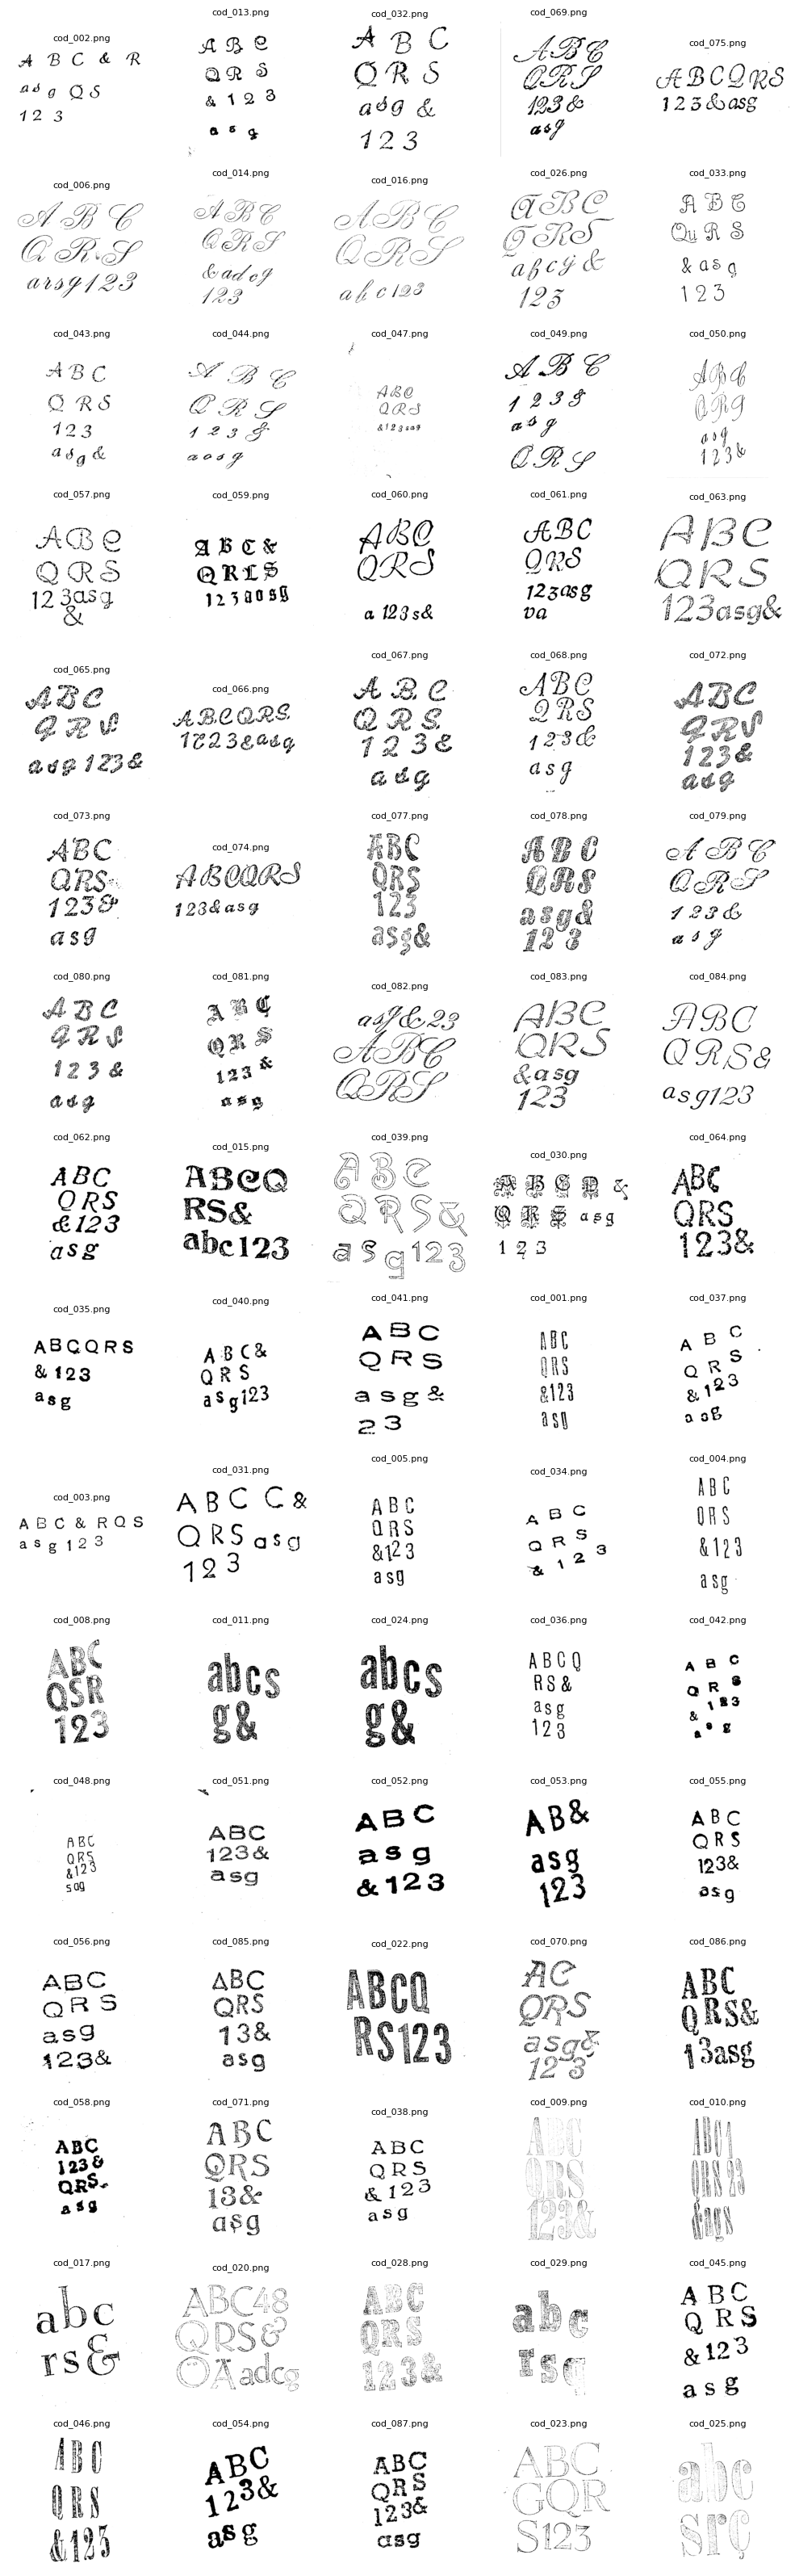

In [7]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/binarized')

### 1.2: Fechamento morfológico
O fechamento morfológico será aplicado para juntar componentes de letras que, por razões diversas (falhas de impressão, iluminação não uniforme, etc.) podem estar desconectadas após a binarização, o que afeta a segmentação que será feita em etapa futura. 

In [ ]:
kernel = np.ones((21,21), np.uint8)

for current_path, subdirectories, files in os.walk(f'{OUTPUT_ROOT_FOLDER}/binarized'):
        if not files: continue
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            style_name = os.path.basename(current_path)
            output_image_dir = os.path.join(f'{OUTPUT_ROOT_FOLDER}/morph_closed', style_name)
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"-> Style: '{style_name}', Image Code: '{image_base_name}'")
            print(f"-> Output will be saved to: {output_image_dir}")

            img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE) 
            
            if img is not None:
                img_inverted = 255 - img
                closing_result = cv.morphologyEx(img_inverted, cv.MORPH_CLOSE, kernel)
                result = 255 - closing_result
                
                cv.imwrite(f'{output_image_dir}/{image_base_name}.png', result)

                print("Saved at ", output_image_dir)


Processing image: data_1/interim/binarized/escritural/cod_002.png
-> Style: 'escritural', Image Code: 'cod_002'
-> Output will be saved to: data_1/interim/morph_closed/escritural
Saved at  data_1/interim/morph_closed/escritural

Processing image: data_1/interim/binarized/escritural/cod_013.png
-> Style: 'escritural', Image Code: 'cod_013'
-> Output will be saved to: data_1/interim/morph_closed/escritural
Saved at  data_1/interim/morph_closed/escritural

Processing image: data_1/interim/binarized/escritural/cod_032.png
-> Style: 'escritural', Image Code: 'cod_032'
-> Output will be saved to: data_1/interim/morph_closed/escritural
Saved at  data_1/interim/morph_closed/escritural

Processing image: data_1/interim/binarized/escritural/cod_069.png
-> Style: 'escritural', Image Code: 'cod_069'
-> Output will be saved to: data_1/interim/morph_closed/escritural
Saved at  data_1/interim/morph_closed/escritural

Processing image: data_1/interim/binarized/escritural/cod_075.png
-> Style: 'escrit

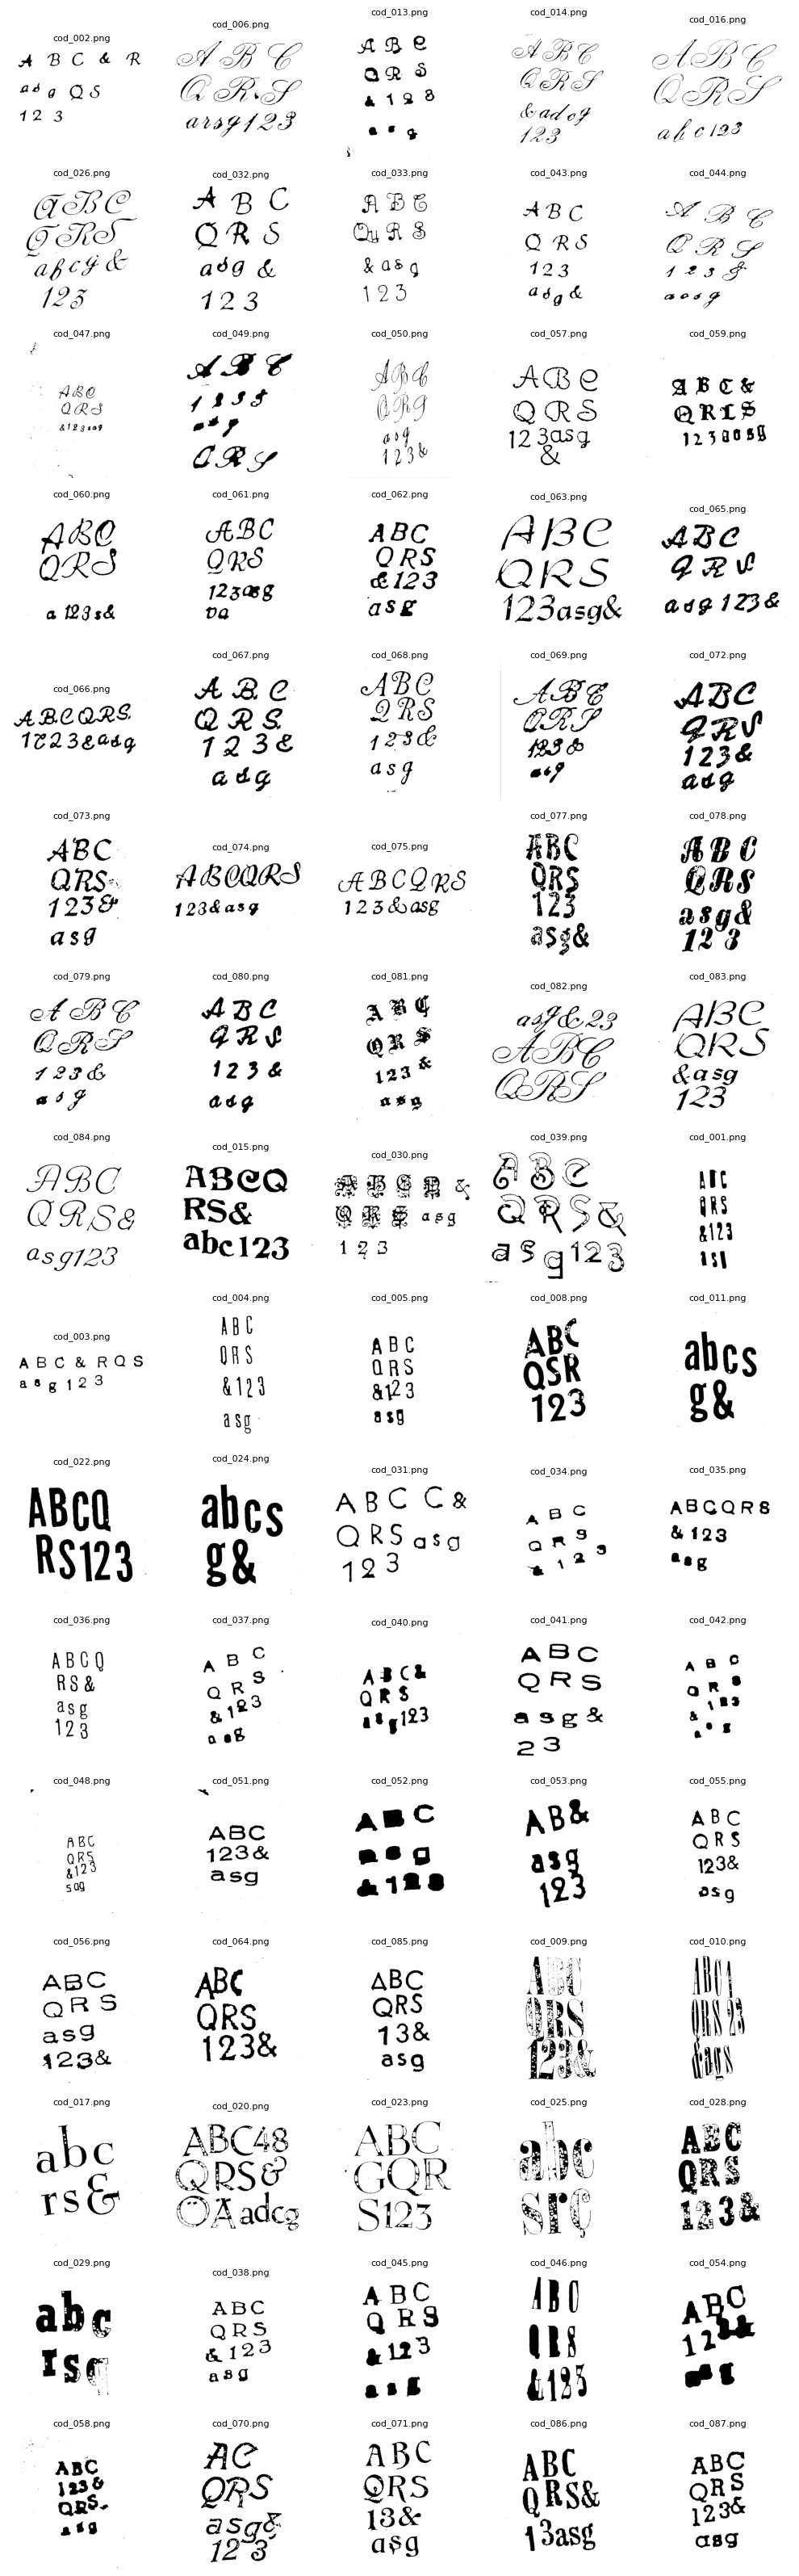

In [10]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/morph_closed')

Apesar de, acima, haver destruição de detalhes das letras (veja `cod_045.png`, por exemplo), estamos interessados apenas nos **bounding boxes**, isto é, nos 'retângulos' que delimitam as letras. O pré-processamento está completo.

## Etapa 2: Segmentação utilizando componentes conexas
A segmentação é feita com base em componentes conexas. São consideradas componentes conexas pixels de valores distintos do fundo (de valor zero) que estão conectadas por vizinhança-8 (cima, baixo, esquerda, direita e diagonais). Cada componente é considerada, portanto, um caracter distinto.

Como dito anteriormente, estamos interessados apenas nos retângulos delimitadores das letras. Com os limites de cada letra em mãos, os recortes serão obtidos **das imagens originais** (localizados nas pastas `raw`).

Utilizamos, para tanto, o módulo `measure` da biblioteca `Scikit-image`. Esse módulo contém duas funções-chave: `measure.label`, que encontra as componentes conexas e estabelece rótulos para cada uma (0 para o fundo, e 1, 2, 3... para cada componente encontrada), e `measure.regionprops`, que extrai características quantitativas de cada objeto encontrado (inclusive delimitações da bounding box) e as guarda em um dicionário indexado pelo rótulo do objeto (ref.: [Documentação skimage.measure](https://scikit-image.org/docs/0.25.x/api/skimage.measure.html))

Trocamos as pastas de origem e destino nesta etapa. `AUX_ROOT_FOLDER` consiste na pasta com as imagens transformadas. `INPUT_ROOT_FOLDER` contém as imagens originais. `OUTPUT_ROOT_FOLDER` conterá os recortes, a partir das imagens originais, das componentes conexas encontradas nas imagens transformadas.

In [11]:
AUX_ROOT_FOLDER = 'data_1/interim/morph_closed'
INPUT_ROOT_FOLDER = 'data_1/raw'
OUTPUT_ROOT_FOLDER = 'data_1/processed'

Abaixo, o código da segmentação. Veja que recortes cujo tamanho/número de pixels/área é menor que 100 não são salvos, como uma maneira de reduzir ruídos remanescentes.

In [12]:
for current_path, subdirectories, files in os.walk(INPUT_ROOT_FOLDER):
        if not files: continue
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue

            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            style_name = os.path.basename(current_path)
            output_image_dir = os.path.join(OUTPUT_ROOT_FOLDER, style_name, image_base_name)
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"  -> Style: '{style_name}', Image Code: '{image_base_name}'")
            print(f"  -> Output will be saved to: {output_image_dir}")

            original_img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE)
            if original_img is None:
                print(f"  -> Error loading image. Skipping...")
                continue
            
            img = cv.imread(os.path.join(AUX_ROOT_FOLDER, style_name, f'{image_base_name}.png'))
            
            labeled_img, num_labels = measure.label(img, connectivity=2, background=255, return_num=True)
            props = measure.regionprops(labeled_img)

            for i in range(0, num_labels):
                bbox = props[i].bbox

                cropped_letter = original_img[bbox[0]:bbox[3], bbox[1]:bbox[4]]
                print(np.size(cropped_letter))

                if np.size(cropped_letter) < 100:
                    continue

                output_filename = f"{image_base_name}_{i:03d}.png"
                output_path = os.path.join(output_image_dir, output_filename)

                cv.imwrite(output_path, cropped_letter)
            


Processing image: data_1/raw/escritural/cod_002.jpg
  -> Style: 'escritural', Image Code: 'cod_002'
  -> Output will be saved to: data_1/processed/escritural/cod_002
40376
24948
30132
33120
38502
13674
41478
13899
25900
14280
18762
13833
18921

Processing image: data_1/raw/escritural/cod_013.jpg
  -> Style: 'escritural', Image Code: 'cod_013'
  -> Output will be saved to: data_1/processed/escritural/cod_013
20234
29929
29120
1
17214
22922
24311
168
4
11780
12177
7930
11413
5475
7482
12720
1
1088
12
2176
80
9

Processing image: data_1/raw/escritural/cod_032.jpg
  -> Style: 'escritural', Image Code: 'cod_032'
  -> Output will be saved to: data_1/processed/escritural/cod_032
97654
79156
82800
102399
64777
111000
28764
62720
36022
26219
35483
25725
47545
1408
11041

Processing image: data_1/raw/escritural/cod_062.jpg
  -> Style: 'escritural', Image Code: 'cod_062'
  -> Output will be saved to: data_1/processed/escritural/cod_062
30251
26969
30927
32964
27150
33200
24940
16665
28372
25912


Exibindo alguns resultados:

`cod_002`

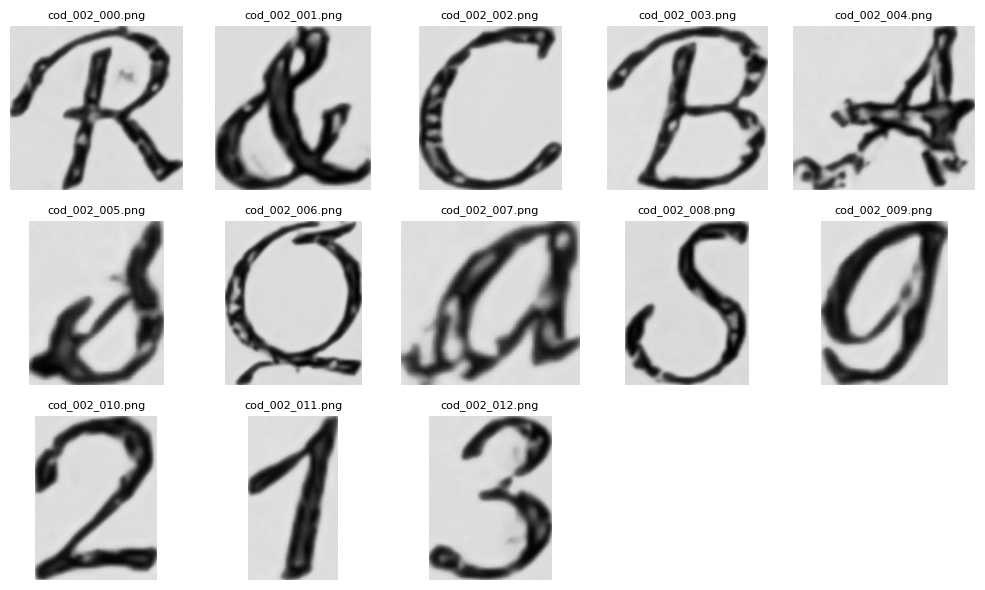

In [13]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/escritural/cod_002')

`cod_072`

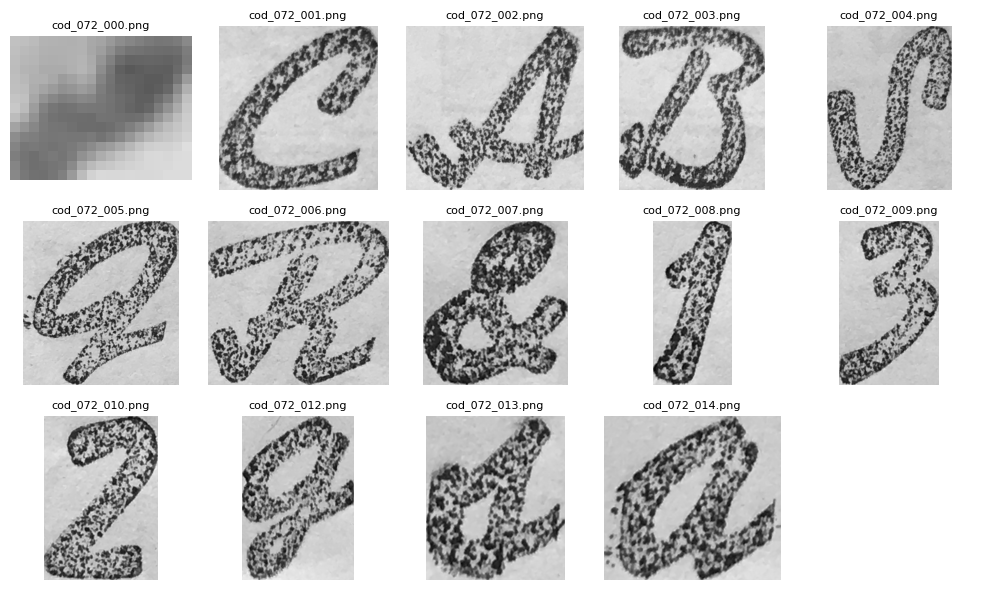

In [14]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/escritural/cod_072')

`cod_039`

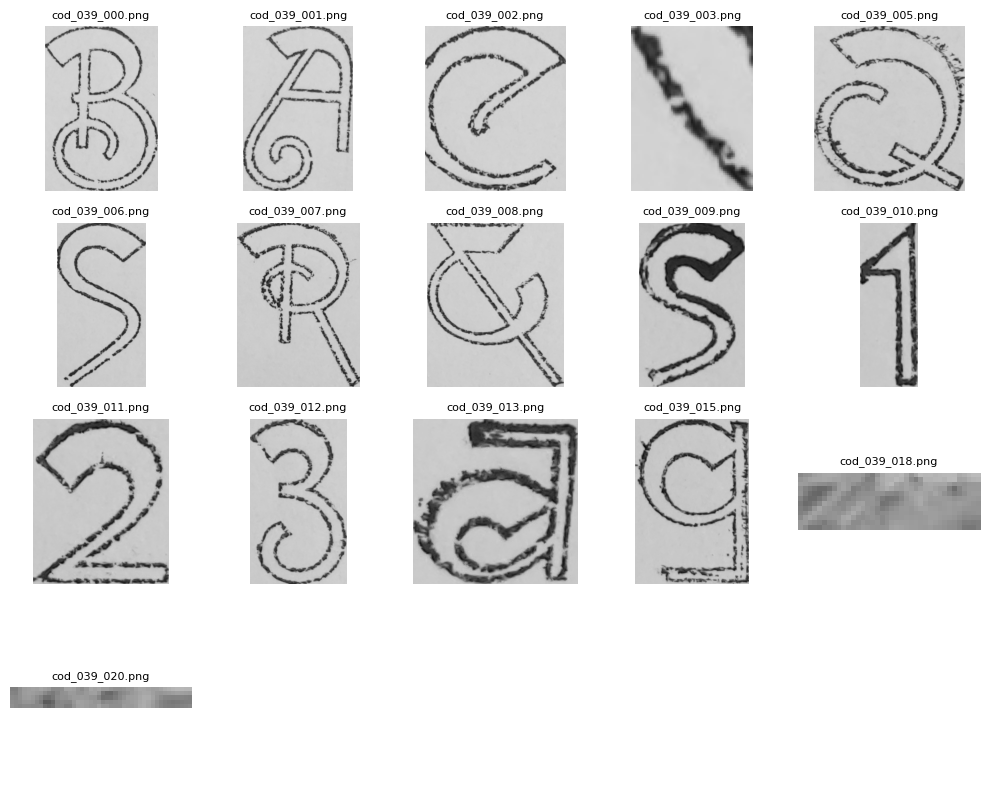

In [15]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/fantasia/cod_039')

`cod_029`

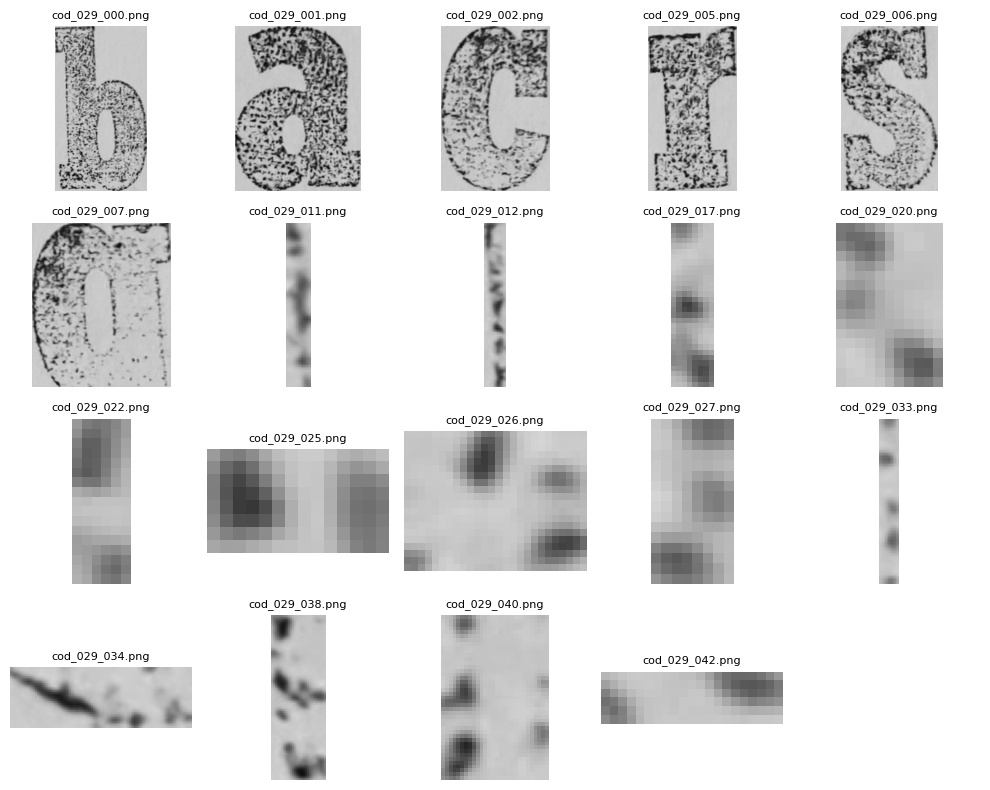

In [16]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/serifado/cod_029')

`cod_050`

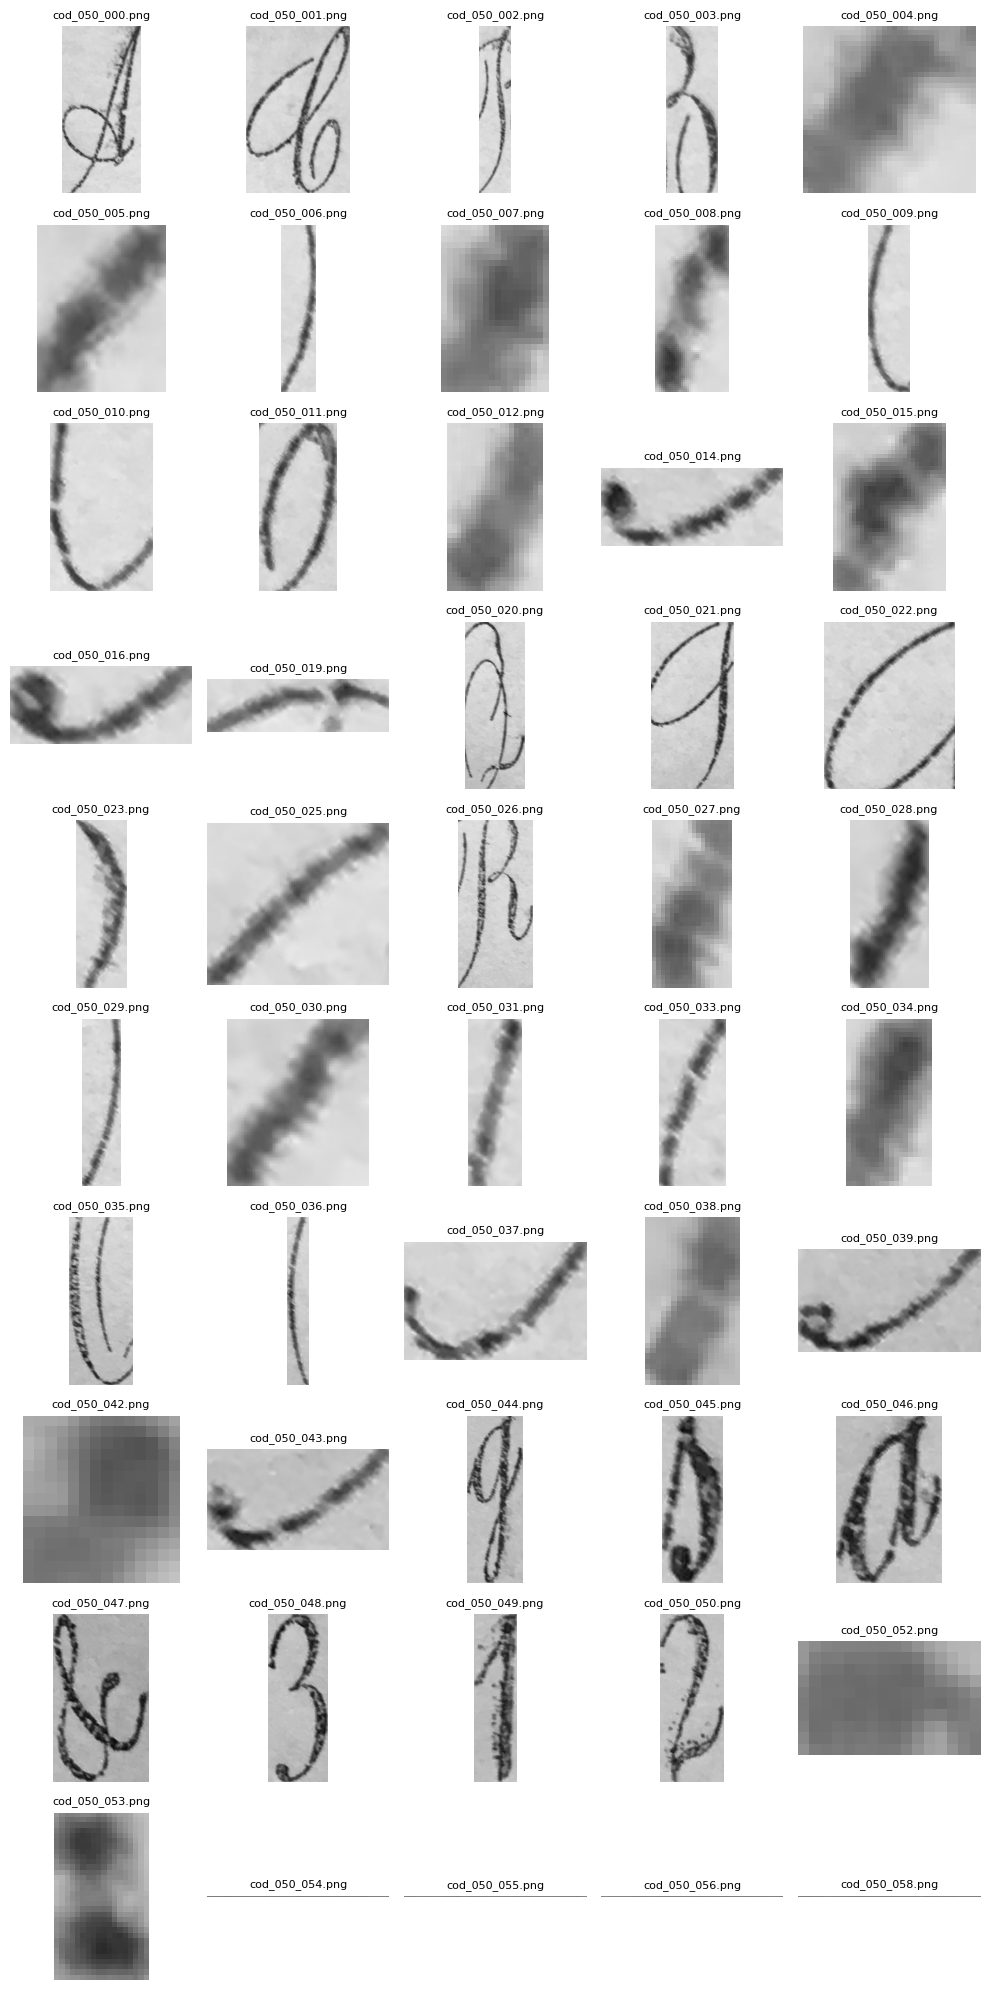

In [17]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/escritural/cod_050')

`cod_015`

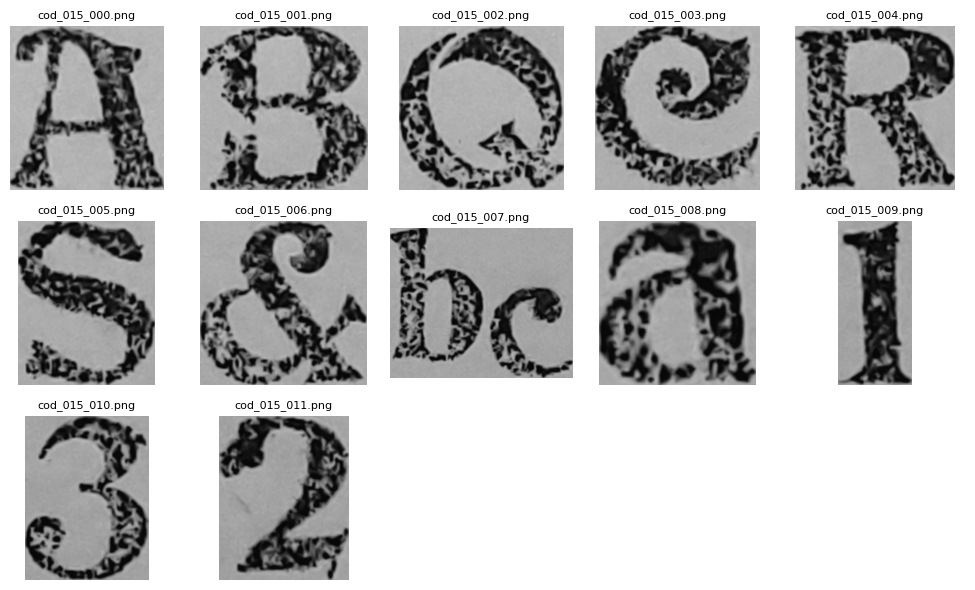

In [18]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/fantasia/cod_015')